<a href="https://colab.research.google.com/github/anisha241001001118/Machine-Learning-Lab/blob/main/Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Question 1

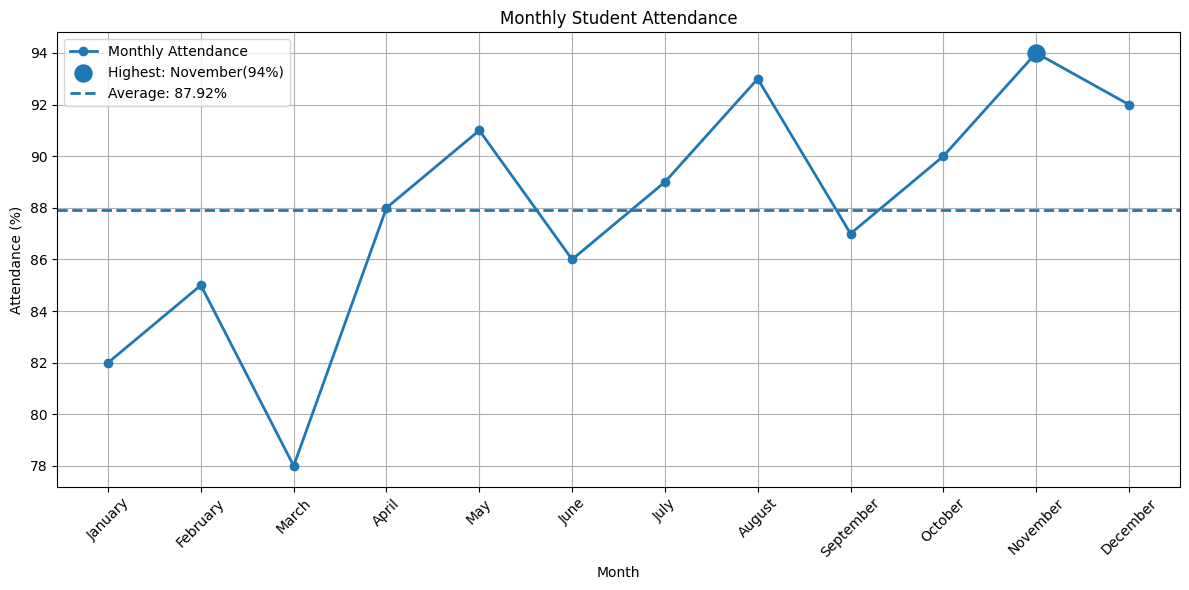

Month with the Highest Attendance: November
Highest Attendance: 94 %
Average Attendance: 87.92 %


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
#data
months=["January","February","March","April","May","June","July","August","September","October","November","December"]
attendance =[82,85,78,88,91,86,89,93,87,90,94,92]
#Calculate average and highest attendance
average_attendance=np.mean(attendance)
highest_attendance=max(attendance)
highest_month=months[attendance.index(highest_attendance)]
#create Line Plot
plt.figure(figsize=(12,6))
plt.plot(
    months,
    attendance,
    marker="o",
    linewidth=2,
    label="Monthly Attendance"
)
#highlight highest attendance
plt.scatter(
    highest_month,
    highest_attendance,
    s=150,
    zorder=5,
    label=f"Highest: {highest_month}({highest_attendance}%)"
)
#Average reference Line
plt.axhline(
    average_attendance,
    linestyle="--",
    linewidth=2,
    label=f"Average: {average_attendance:.2f}%"
)
#Labels and tittles
plt.title("Monthly Student Attendance")
plt.xlabel("Month")
plt.ylabel("Attendance (%)")
#Grid and legend
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#print results
print("Month with the Highest Attendance:",highest_month)
print("Highest Attendance:",highest_attendance,"%")
print("Average Attendance:",round(average_attendance,2),"%")

# Question 2

Dataframe:
   Experience  Salary Department
0           1     3.2        CSE
1           2     4.1        ECE
2           3     5.0        CSE
3           4     5.8         IT
4           5     6.5        CSE
5           6     7.2        ECE
6           7     8.1         IT
7           8     9.0        CSE
8           9     9.8        ECE
9          10    11.0         IT


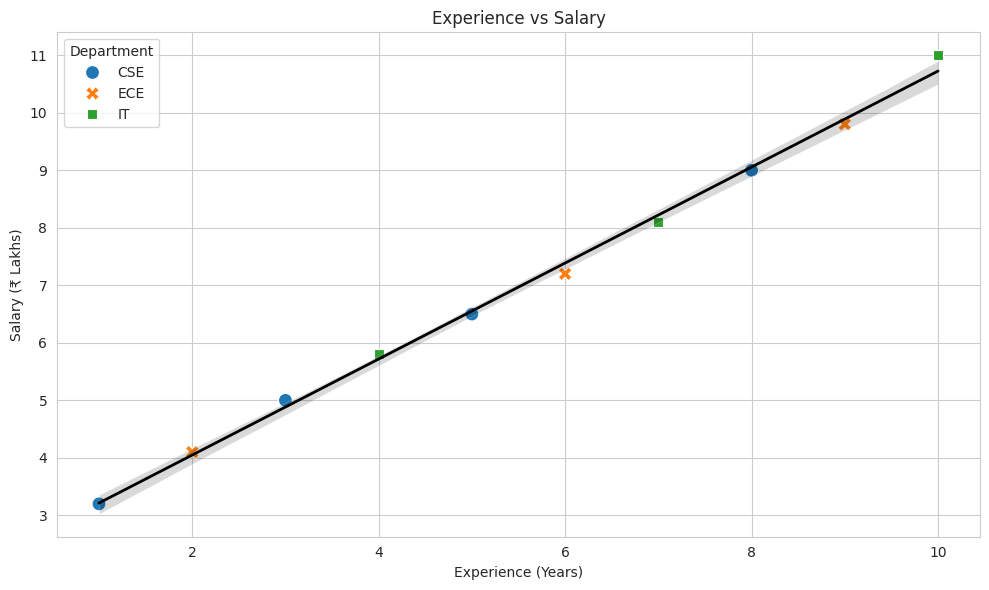

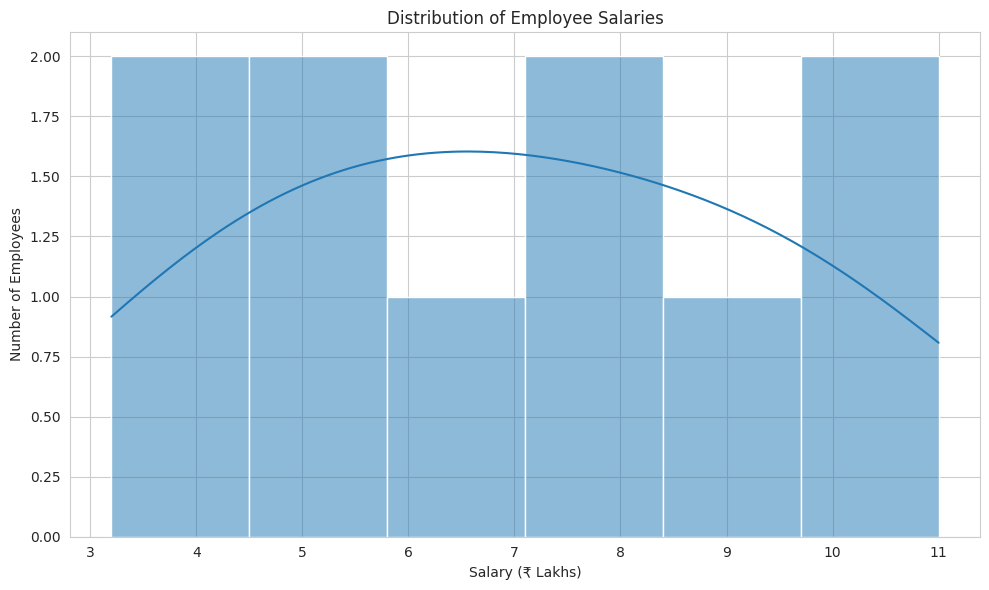

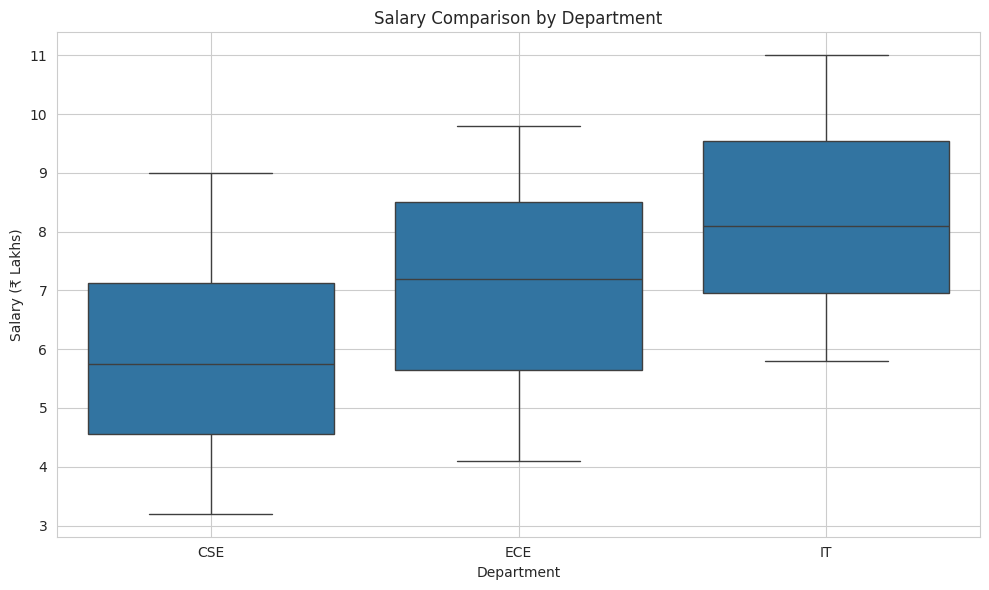


Observations:
1.Salary generally increases as years of experience increase.
2.The regression line shows a strong positive relationship between experience and salary
3.Salary distribution vary across departments,with IT having some of the higher salaries


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#Create Dataframe
data={
     "Experience": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
      "Salary": [3.2, 4.1, 5.0, 5.8, 6.5, 7.2, 8.1, 9.0, 9.8, 11.0],
      "Department": ["CSE", "ECE", "CSE", "IT", "CSE","ECE", "IT", "CSE", "ECE", "IT"]
}
df=pd.DataFrame(data)
print("Dataframe:")
print(df)
# Set Seaborn style
sns.set_style("whitegrid")
# 1. Scatter plot with regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Experience",
    y="Salary",
    hue="Department",
    style="Department",
    s=100
)
sns.regplot(
    data=df,
    x="Experience",
    y="Salary",
    scatter=False,
    color="black",
    line_kws={"linewidth": 2}
)
plt.title("Experience vs Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary (₹ Lakhs)")
plt.legend(title="Department")
plt.grid(True)
plt.tight_layout()
plt.show()
# 2. Salary Distribution plot
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="Salary",
    kde=True,
    bins=6
)
plt.title("Distribution of Employee Salaries")
plt.xlabel("Salary (₹ Lakhs)")
plt.ylabel("Number of Employees")
plt.grid(True)
plt.tight_layout()
plt.show()
# 3. Box plot comparing salaraies by department
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="Department",
    y="Salary"
)
plt.title("Salary Comparison by Department")
plt.xlabel("Department")
plt.ylabel("Salary (₹ Lakhs)")
plt.grid(True)
plt.tight_layout()
plt.show()
#Observations
print("\nObservations:")
print("1.Salary generally increases as years of experience increase.")
print("2.The regression line shows a strong positive relationship between experience and salary")
print("3.Salary distribution vary across departments,with IT having some of the higher salaries")

# Question 3

Dataset:
    Area  Price
0    800     32
1   1000     40
2   1200     48
3   1400     55
4   1600     63
5   1800     70
6   2000     78
7   2200     85
8   2400     94
9   2600    102
10  2800    110
11  3000    118

Basic Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Area    12 non-null     int64
 1   Price   12 non-null     int64
dtypes: int64(2)
memory usage: 324.0 bytes
None

Statistical Summary:
              Area       Price
count    12.000000   12.000000
mean   1900.000000   74.583333
std     721.110255   28.030692
min     800.000000   32.000000
25%    1350.000000   53.250000
50%    1900.000000   74.000000
75%    2450.000000   96.000000
max    3000.000000  118.000000

Missing Values:
Area     0
Price    0
dtype: int64

Model Coefficient (Slope): 0.03873603351955306
Model Intercept: 0.8868715083798975

Actual vs Predicted Prices:
    Are

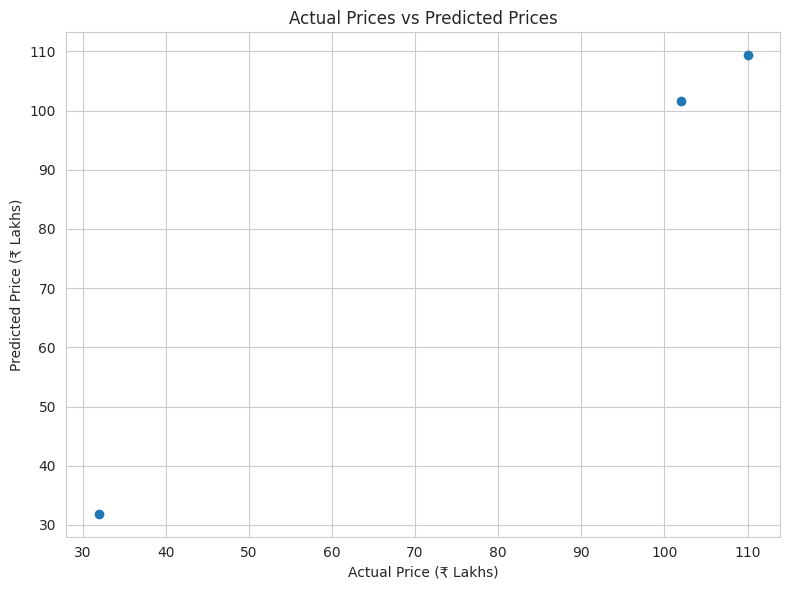

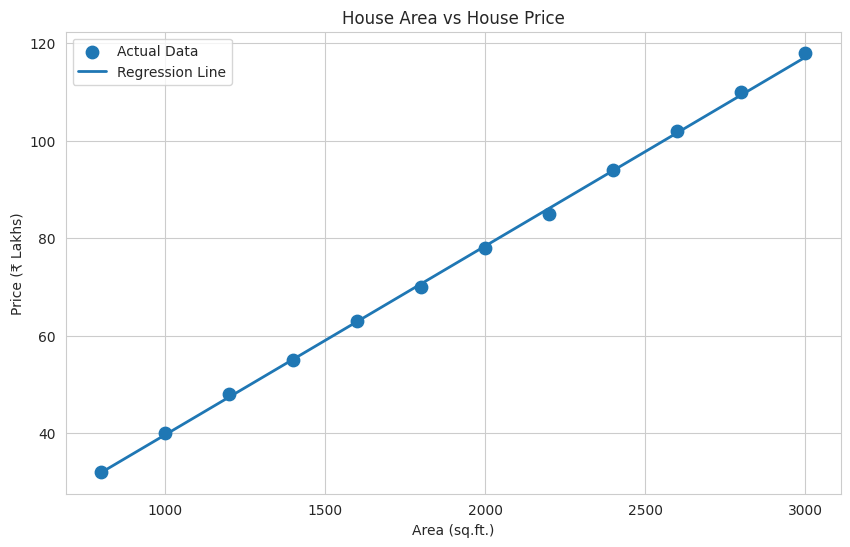


Model Interpretation
The model provides a good fit because the R² score is high.


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
# Create dataset
data = {
    "Area": [
        800, 1000, 1200, 1400,
        1600, 1800, 2000, 2200,
        2400, 2600, 2800, 3000
    ],

    "Price": [
        32, 40, 48, 55,
        63, 70, 78, 85,
        94, 102, 110, 118
    ]
}
df = pd.DataFrame(data)
# Display dataset
print("Dataset:")
print(df)
# Basic data analysis
print("\nBasic Information:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())
# Define input and output
X = df[["Area"]]
y = df["Price"]
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)
# Display coefficient and intercept
print("\nModel Coefficient (Slope):", model.coef_[0])
print("Model Intercept:", model.intercept_)
# Predict test data
y_pred = model.predict(X_test)
print("\nActual vs Predicted Prices:")
results = pd.DataFrame({
    "Area": X_test["Area"],
    "Actual Price": y_test,
    "Predicted Price": y_pred
})
print(results.sort_values("Area"))
# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("\nEvaluation Metrics:")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)
# Predict price for 2500 sq.ft
area_2500 = pd.DataFrame({"Area": [2500]})
predicted_price = model.predict(area_2500)
print("\nPredicted price for 2500 sq.ft:",
    round(predicted_price[0], 2),"Lakhs")
#-------------------------------------------
# Plot 1: Actual Prices vs Predicted Prices
#-------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(
    y_test,
    y_pred,
    label="Predicted Prices"
)
#Perfect prediction reference line
min_value = min(y_test.min(),y_pred.min())
max_value = max(y_test.min(),y_pred.min())
plt.plot(
    [min_value,max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect Prediction"
)
plt.title("Actual Prices vs Predicted Prices")
plt.xlabel("Actual Price (₹ Lakhs)")
plt.ylabel("Predicted Price (₹ Lakhs)")
plt.grid(True)
plt.tight_layout()
plt.show()
#------------------------
# Plot 2: Regression Line
#------------------------
plt.figure(figsize=(10, 6))
plt.scatter(
    df["Area"],
    df["Price"],
    s=80,
    label="Actual Data"
)
#generate values for regression line
area_range = np.linspace(
    df["Area"].min(),
    df["Area"].max(),
    100
).reshape(-1,1)
plt.plot(
    area_range,
    price_prediction,
    linewidth=2,
    label="Regression Line"
)
plt.xlabel("Area (sq.ft.)")
plt.ylabel("Price (₹ Lakhs)")
plt.title("House Area vs House Price")
plt.grid(True)
plt.legend()
plt.show()
# Model Interpretation
print("\nModel Interpretation")
if r2>=0.8:
  print("The model provides a good fit because the R² score is high.")
else:
  print("The model does not provide a good fit because the R² score is relatively low.")